<a href="https://colab.research.google.com/github/shin584/project/blob/1D_models/Cas12a_model3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project'
file_name = 'Copy of kim_2018_cas12a_dataset.xlsx'

file_path = os.path.join(base_path, file_name)
if os.path.exists(file_path):
  print(f"파일을 찾았습니다! 경로: {file_path}")
else:
  print(f"파일을 찾을 수 없습니다. 경로를 다시 확인해주세요: {file_path}")

Mounted at /content/drive
파일을 찾았습니다! 경로: /content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project/Copy of kim_2018_cas12a_dataset.xlsx


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


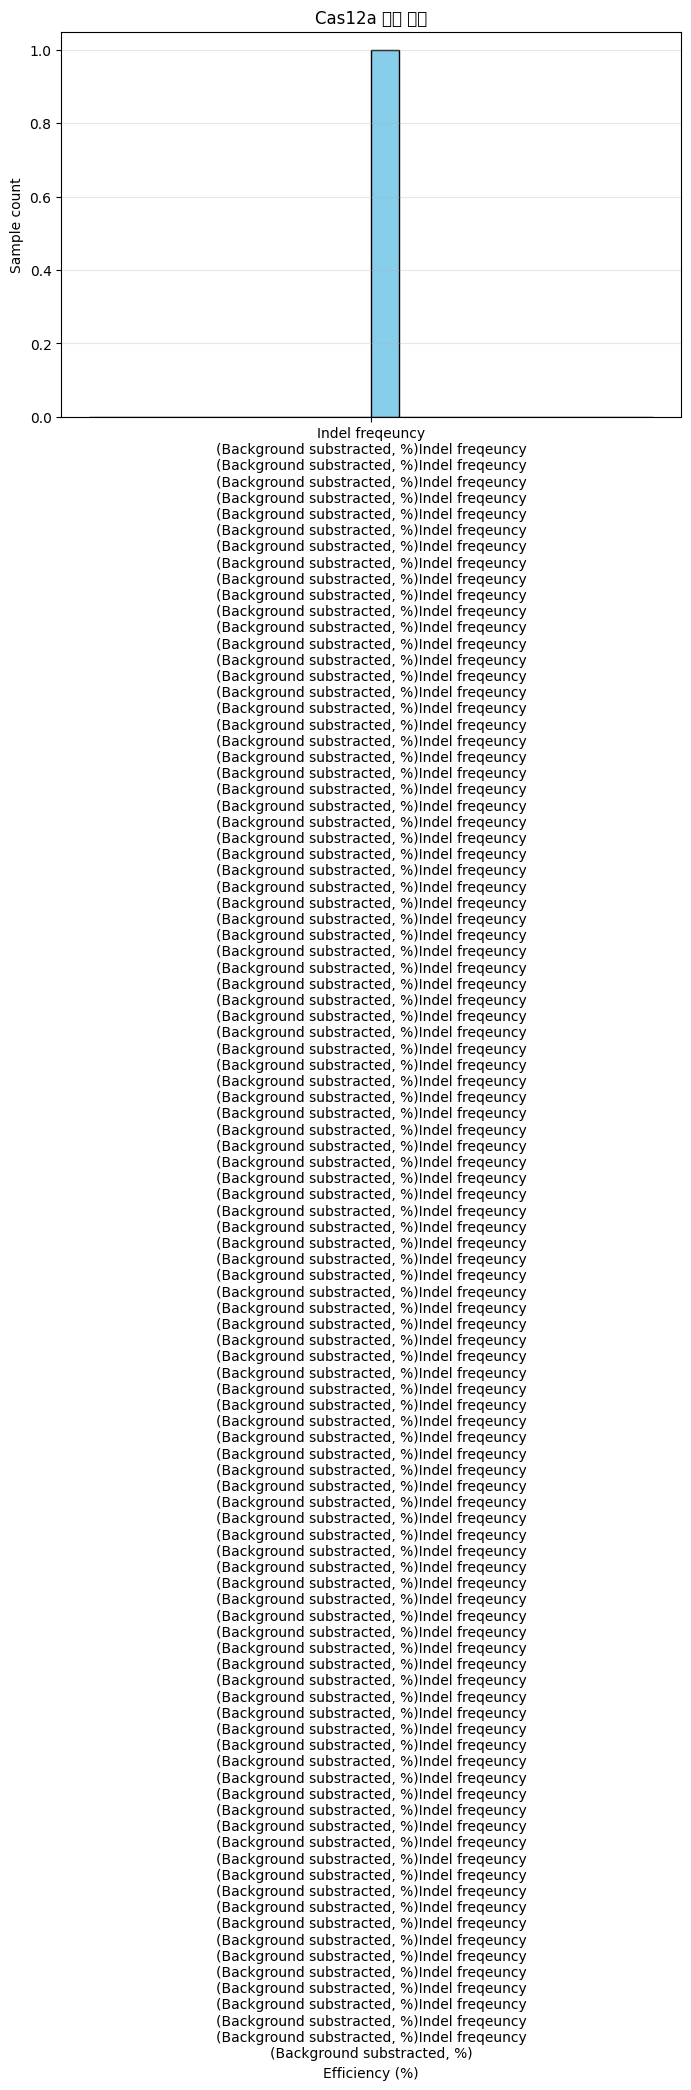

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if file_name.endswith(('.csv', '.txt')):
    df = pd.read_csv(file_path)
    if len(df.columns) < 2:
        df = pd.read_csv(file_path, sep='\t')
elif file_path.endswith('.tsv'):
    df = pd.read_csv(file_path, sep='\t')
elif file_path.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Unsupported file format. Please provide a CSV, TSV, or Excel file.")

y = 'Indel freqeuncy\n(Background substracted, %)'
# y: Cas12a 효율값 (0~1로 정규화 되어 있다고 가정)
y_pct = y * 100  # 0~100%로 변환

# 히스토그램
plt.figure(figsize=(8,5))
plt.hist(y_pct, bins=20, color='skyblue', edgecolor='black')
plt.title("Cas12a 효율 분포")
plt.xlabel("Efficiency (%)")
plt.ylabel("Sample count")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 구간별 샘플 수
low_count  = np.sum(y_pct < 20)
mid_count  = np.sum((y_pct >= 20) & (y_pct < 60))
high_count = np.sum(y_pct >= 60)

print(f"저효율(0~20%)   : {low_count}개")
print(f"중효율(20~60%)  : {mid_count}개")
print(f"고효율(60~100%) : {high_count}개")

Cas12a 데이터 로딩 중...
컬럼 목록: ['50 bp synthetic target and target context sequence \n10 bp + PAM + 23 bp protospacer + 17 bp)', '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)', "20 bp guide sequence (5' to 3')", 'Indel frequency\n(%, Background)', 'Indel read count\n(Background)', 'Total read count\n(Background)', 'Indel freqeuncy\n(Cpf1 delivered,%)', 'Indel read count\n(Cpf1 delivered)', 'Total read count\n(Cpf1 delivered)', 'Indel freqeuncy\n(Background substracted, %)']
전체 행 수: 15002

서열 컬럼  : '34 bp synthetic target and target context sequence
(4 bp + PAM + 23 bp protospacer + 3 bp)'
타겟 컬럼  : 'Indel freqeuncy
(Background substracted, %)'
결측치 제거: 15002 -> 15000개
최종 데이터: X=(15000, 34, 4), y=(15000,)
타겟 범위  : 0.0% ~ 100.0%
학습: 12000개 / 검증: 3000개


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Seq (InputLayer)          │ (None, 34, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv1D)                  │ (None, 34, 64)         │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 34, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LReLU1 (LeakyReLU)              │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop1 (Dropout)                 │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM (Bidirectional)          │ (None, 34, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop3 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,169 (121.75 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 128 (512.00 B)


Cas12a 모델 학습 시작...
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0849 - mae: 0.2474 - val_loss: 0.0747 - val_mae: 0.2281 - learning_rate: 5.0000e-04
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - loss: 0.0704 - mae: 0.2168 - val_loss: 0.0715 - val_mae: 0.2040 - learning_rate: 5.0000e-04
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0587 - mae: 0.1908 - val_loss: 0.0532 - val_mae: 0.1784 - learning_rate: 5.0000e-04
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0544 - mae: 0.1824 - val_loss: 0.0508 - val_mae: 0.1727 - learning_rate: 5.0000e-04
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - loss: 0.0524 - mae: 0.1771 - val_loss: 0.0493 - val_mae: 0.1708 - learning_rate: 5.0000e-04
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0511 - mae: 0.1747 - val_loss: 0.0496 - val_mae: 0.1674 - learning_rate: 5.0000e-04
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0501 - mae: 0.1721 - 

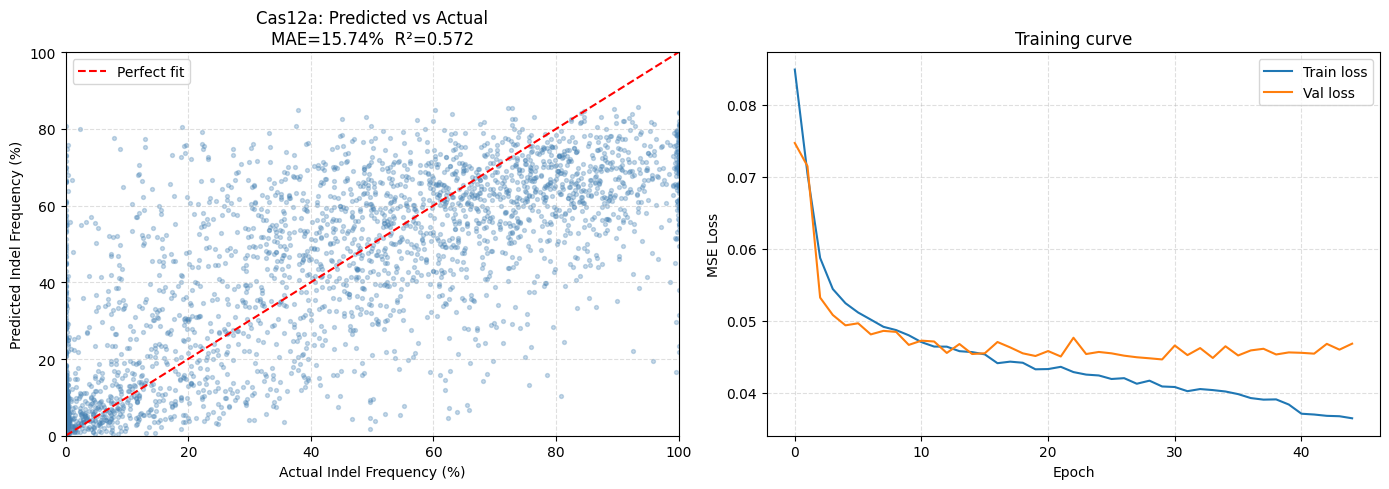


[추론 테스트]
--------------------------------------------------
서열    : ATCG[TTTA]ATCGATCGATCGATCGATCGATCGTA
PAM     : TTTA
예측 Indel frequency: 0.47%
결과: 보통 절단 효율 (Moderate efficiency)
--------------------------------------------------
[Error] 서열 길이가 맞지 않습니다. (현재: 4bp / 필요: 34bp)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, BatchNormalization, Dropout, Bidirectional, LSTM, GlobalAveragePooling1D, GlobalMaxPooling1D, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# =============================================================
# 1. 서열 인코딩
# =============================================================
def one_hot_encode(sequence):
  mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
  sequence = sequence.upper()
  return np.array([mapping.get(base, [0,0,0,0]) for base in sequence])

# =============================================================
# 2. 데이터 로더
#    Cas12a 데이터 컬럼 구조:
#      - '34mer' (또는 유사한 이름): 34bp 서열
#      - 'Indel frequency (Background subtracted, %)': 타겟 변수
# =============================================================
def load_cas12a_dataset(filepath):
    print("Cas12a 데이터 로딩 중...")

    # --- 파일 읽기 (csv / tsv / excel 자동 감지) ---
    if filepath.endswith(('.csv', '.txt')):
        df = pd.read_csv(filepath)
        if len(df.columns) < 2:
            df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith('.tsv'):
        df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a CSV, TSV, or Excel file.")
    print(f"컬럼 목록: {list(df.columns)}")
    print(f"전체 행 수: {len(df)}")

    seq_col    = '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)'
    target_col = 'Indel freqeuncy\n(Background substracted, %)'

    print(f"\n서열 컬럼  : '{seq_col}'")
    print(f"타겟 컬럼  : '{target_col}'")

    # --- 결측치 제거 ---
    original_len = len(df)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[seq_col, target_col])
    print(f"결측치 제거: {original_len} -> {len(df)}개")

    # --- 전처리 ---
    X, y = [], []

    for _, row in df.iterrows():
        seq   = str(row[seq_col]).strip().upper()
        score = float(row[target_col])

        # 길이 보정: 34bp 고정
        if len(seq) > 34:
            seq = seq[:34]
        elif len(seq) < 34:
            seq = seq + ('N' * (34 - len(seq)))  # 짧으면 N으로 패딩

        X.append(one_hot_encode(seq))
        y.append(score / 100.0)  # 0~100% -> 0~1 정규화 (sigmoid 출력과 맞추기 위해)

    X = np.array(X, dtype=np.float32)   # shape: (N, 34, 4)
    y = np.array(y, dtype=np.float32)   # shape: (N,)
    y = np.clip(y, 0, 1)

    print(f"최종 데이터: X={X.shape}, y={y.shape}")
    print(f"타겟 범위  : {y.min()*100:.1f}% ~ {y.max()*100:.1f}%")
    return X, y

# =============================================================
# 3. 모델 설계
#    SaCas9 모델과 거의 같은 구조.
#    달라진 점:
#      - 입력 shape: (36, 4) -> (34, 4)  [Cas12a 서열 길이]
#      - Conv block 1: kernel=4           [PAM=TTTV 4bp 직접 포착]
#      - Conv block 2: kernel=7           [로컬 맥락 확장]
# =============================================================
def create_cas12a_model():

    # 입력: 34bp (4bp context + 4bp PAM + 23bp protospacer + 3bp context)
    input_layer = Input(shape=(34, 4), name='Input_Seq')

    x = Conv1D(filters=64, kernel_size=7, padding='same', name='Conv1')(input_layer)
    x = BatchNormalization(name='BN1')(x)
    x = LeakyReLU(negative_slope=0.1, name='LReLU1')(x)
    x = Dropout(0.3, name='Drop1')(x)

    x = Bidirectional(LSTM(32, return_sequences=True), name='BiLSTM')(x)
    x = Dropout(0.3, name='Drop2')(x)

    x = GlobalAveragePooling1D(name='GAP')(x)

    x = Dense(64, activation='relu', name='Dense1')(x)
    x = Dropout(0.3, name='Drop3')(x)

    output_layer = Dense(1, activation='sigmoid', name='Output')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )

    return model


# =============================================================
# 4. 학습
# =============================================================
def train_cas12a_model(X, y):

    # --- 데이터 분리 (train 80% / val 20%) ---

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"학습: {len(X_train)}개 / 검증: {len(X_val)}개")

    # --- 모델 생성 ---
    model = create_cas12a_model()
    model.summary()

    # --- 콜백 ---
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,    # 학습률을 절반으로
        patience=10,
        min_lr=1e-6
    )

    # --- 학습 ---
    print("\nCas12a 모델 학습 시작...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # --- 저장 ---
    # 모델 저장 경로 설정 (없으면 생성)
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)
    model_save_path = os.path.join(model_save_dir, 'cas12a_model.keras')

    model.save(model_save_path)
    print(f"\n모델 저장 완료: {model_save_path}")

    return model, history, X_val, y_val



# =============================================================
# 5. 평가 및 시각화
# =============================================================
def evaluate_and_plot(model, X_val, y_val, history):

    # 예측
    y_pred = model.predict(X_val, verbose=0).flatten()

    # 0~1 -> 0~100 스케일 복원
    y_true_pct = y_val  * 100
    y_pred_pct = y_pred * 100

    mae = mean_absolute_error(y_true_pct, y_pred_pct)
    r2  = r2_score(y_true_pct, y_pred_pct)

    print(f"\n검증 성능")
    print(f"  MAE : {mae:.2f}%")
    print(f"  R²  : {r2:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- 그래프 1: 예측 vs 실제 ---
    ax = axes[0]
    ax.scatter(y_true_pct, y_pred_pct, alpha=0.3, s=8, color='steelblue')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"Cas12a: Predicted vs Actual\nMAE={mae:.2f}%  R²={r2:.3f}", fontsize=12)
    ax.set_xlabel("Actual Indel Frequency (%)")
    ax.set_ylabel("Predicted Indel Frequency (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

    # --- 그래프 2: 학습 곡선 ---
    ax2 = axes[1]
    ax2.plot(history.history['loss'],     label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title("Training curve", fontsize=12)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE Loss")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# =============================================================
# 6. 추론 함수
#    SaCas9의 predict_sacas9()와 동일한 인터페이스
# =============================================================
def predict_cas12a(sequence, model):
    """
    입력: 34bp DNA 서열 (4bp context + TTTV PAM + 23bp protospacer + 3bp context)
    출력: Indel frequency 예측값 (%)
    """
    seq = sequence.strip().upper()

    if len(seq) != 34:
        print(f"[Error] 서열 길이가 맞지 않습니다. (현재: {len(seq)}bp / 필요: 34bp)")
        return None

    # PAM 위치 추출 및 표시 (5~8번째 bp, 인덱스 4~7)
    pam_seq = seq[4:8]

    enc   = one_hot_encode(seq)
    input_data = enc.reshape(1, 34, 4)

    score = model.predict(input_data, verbose=0)[0][0]

    print(f"서열    : {seq[:4]}[{pam_seq}]{seq[8:]}")
    print(f"PAM     : {pam_seq}")
    print(f"예측 Indel frequency: {score:.2f}%")

    if score > 0.6:
        print("결과: 높은 절단 효율 (High efficiency)")
    elif score > 0.3:
        print("결과: 보통 절단 효율 (Moderate efficiency)")
    else:
        print("결과: 낮은 절단 효율 (Low efficiency)")

    return score

# =============================================================
# 7. 실행
# =============================================================
if __name__ == '__main__':

    # 모델 저장 경로 설정 (없으면 생성)
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)
    model_save_path = os.path.join(model_save_dir, 'cas12a_model.keras')

    # --- 학습 ---
    if os.path.exists(file_path):
        X, y = load_cas12a_dataset(file_path)
        model, history, X_val, y_val = train_cas12a_model(X, y)
        evaluate_and_plot(model, X_val, y_val, history)
    else:
        print(f"파일을 찾을 수 없습니다: {file_path}")

    # --- 추론 테스트 ---
    # 저장된 모델 불러오기
    if os.path.exists(model_save_path):
        loaded_model = tf.keras.models.load_model(model_save_path)

        print("\n[추론 테스트]")
        print("-" * 50)

        # TEST 1: TTTV PAM이 포함된 서열 (정상 케이스)
        seq_test1 = "ATCGTTTAATCGATCGATCGATCGATCGATCGTA"  # 34bp (예시)
        predict_cas12a(seq_test1, loaded_model)

        print("-" * 50)

        # TEST 2: 길이 오류 케이스
        seq_error = "ATCG"
        predict_cas12a(seq_error, loaded_model)


Cas12a 데이터 로딩 중...
컬럼 목록: ['50 bp synthetic target and target context sequence \n10 bp + PAM + 23 bp protospacer + 17 bp)', '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)', "20 bp guide sequence (5' to 3')", 'Indel frequency\n(%, Background)', 'Indel read count\n(Background)', 'Total read count\n(Background)', 'Indel freqeuncy\n(Cpf1 delivered,%)', 'Indel read count\n(Cpf1 delivered)', 'Total read count\n(Cpf1 delivered)', 'Indel freqeuncy\n(Background substracted, %)']
전체 행 수: 15002

서열 컬럼  : '34 bp synthetic target and target context sequence
(4 bp + PAM + 23 bp protospacer + 3 bp)'
타겟 컬럼  : 'Indel freqeuncy
(Background substracted, %)'
결측치 제거: 15002 -> 15000개


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Seq           │ (None, 34, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv1D)      │ (None, 34, 128)   │      2,176 │ Input_Seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 128)   │        512 │ Conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 34, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 34, 128)   │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2 (Conv1D)      │ (None, 34, 64)    │     57,408 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 64)    │        256 │ Conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 34, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 34, 64)    │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 34, 64)    │     24,832 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Feat          │ (None, 354)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 34, 64)    │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     22,720 │ Input_Feat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ dropout_7[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 116,225 (454.00 KB)

 Trainable params: 115,841 (452.50 KB)

 Non-trainable params: 384 (1.50 KB)


Cas12a 모델 학습 시작...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - loss: 0.0816 - mae: 0.2383 - val_loss: 0.0893 - val_mae: 0.2321 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - loss: 0.0575 - mae: 0.1885 - val_loss: 0.0526 - val_mae: 0.1686 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.0484 - mae: 0.1685 - val_loss: 0.0524 - val_mae: 0.1703 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 0.0435 - mae: 0.1581 - val_loss: 0.0459 - val_mae: 0.1577 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0402 - mae: 0.1513 - val_loss: 0.0458 - val_mae: 0.1548 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - loss: 0.0376 - mae: 0.1458 - val_loss: 0.0453 - val_mae: 0.1563 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 0.0346 - mae: 0.1406 - val_loss: 0.0476 - val_mae: 0.1

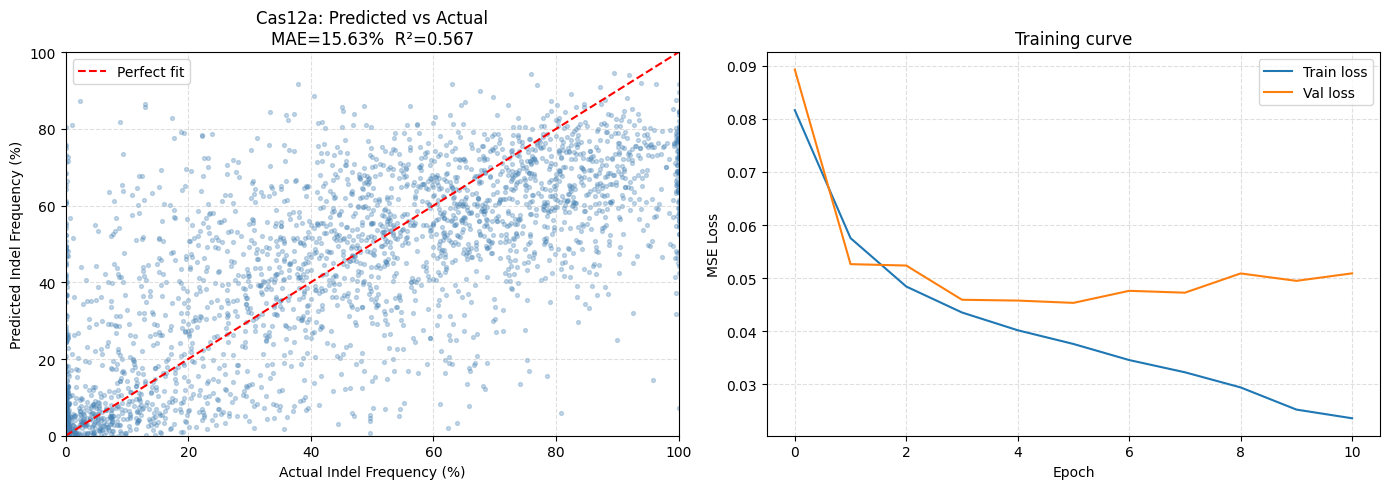


[추론 테스트]
--------------------------------------------------
[Error] 서열 길이가 맞지 않습니다. (현재: 33bp / 필요: 34bp)
--------------------------------------------------
[Error] 서열 길이가 맞지 않습니다. (현재: 4bp / 필요: 34bp)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, BatchNormalization, Dropout, Bidirectional, LSTM, GlobalAveragePooling1D, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# =============================================================
# 1. 서열 인코딩
# =============================================================
def one_hot_encode(sequence):
  mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
  sequence = sequence.upper()
  return np.array([mapping.get(base, [0,0,0,0]) for base in sequence])

def extract_seq_features(seq):
    protospacer = seq[8:31]  # 23bp protospacer

    # GC content
    gc_total = (protospacer.count('G') + protospacer.count('C')) / 23
    gc_seed  = (protospacer[-8:].count('G') + protospacer[-8:].count('C')) / 8

    # Dinucleotide (22쌍, 각 16가지 one-hot)
    dinuc_map = {a+b: i for i, (a,b) in enumerate(
        [x+y for x in 'ACGT' for y in 'ACGT']
    )}
    dinuc_features = np.zeros(22 * 16, dtype=np.float32)
    for i in range(22):
        pair = protospacer[i:i+2]
        if pair in dinuc_map:
            dinuc_features[i * 16 + dinuc_map[pair]] = 1.0

    return np.array([gc_total, gc_seed], dtype=np.float32), dinuc_features

# =============================================================
# 2. 데이터 로더
#    Cas12a 데이터 컬럼 구조:
#      - '34mer' (또는 유사한 이름): 34bp 서열
#      - 'Indel frequency (Background subtracted, %)': 타겟 변수
# =============================================================



def load_cas12a_dataset(filepath):
    print("Cas12a 데이터 로딩 중...")

    # --- 파일 읽기 (csv / tsv / excel 자동 감지) ---
    if filepath.endswith(('.csv', '.tsv', '.txt')):
        try:
            df = pd.read_csv(filepath)
            if len(df.columns) < 2:
                df = pd.read_csv(filepath, sep='\t')
        except Exception:
            df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a CSV, TSV, or Excel file.")

    print(f"컬럼 목록: {list(df.columns)}")
    print(f"전체 행 수: {len(df)}")

    seq_col    = '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)'
    target_col = 'Indel freqeuncy\n(Background substracted, %)'

    print(f"\n서열 컬럼  : '{seq_col}'")
    print(f"타겟 컬럼  : '{target_col}'")

    # --- 결측치 제거 ---
    original_len = len(df)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[seq_col, target_col])
    print(f"결측치 제거: {original_len} -> {len(df)}개")

    # --- 전처리 ---
    X_seq, X_feat, y = [], [], []

    for _, row in df.iterrows():
        seq   = str(row[seq_col]).strip().upper()
        score = float(row[target_col])

        if len(seq) > 34:
            seq = seq[:34]
        elif len(seq) < 34:
            seq = seq + ('N' * (34 - len(seq)))

        gc_feat, dinuc_feat = extract_seq_features(seq)
        extra = np.concatenate([gc_feat, dinuc_feat])  # shape: (354,)

        X_seq.append(one_hot_encode(seq))
        X_feat.append(extra)
        y.append(score / 100.0)

    X_seq  = np.array(X_seq,  dtype=np.float32)   # (N, 34, 4)
    X_feat = np.array(X_feat, dtype=np.float32)   # (N, 354)
    y      = np.array(y,      dtype=np.float32)

    return X_seq, X_feat, y  # 반환값 3개로 변경

# =============================================================
# 3. 모델 설계
#    SaCas9 모델과 거의 같은 구조.
#    달라진 점:
#      - 입력 shape: (36, 4) -> (34, 4)  [Cas12a 서열 길이]
#      - Conv block 1: kernel=4           [PAM=TTTV 4bp 직접 포착]
#      - Conv block 2: kernel=7           [로컬 맥락 확장]
# =============================================================
def create_cas12a_model():
    # 기존 서열 입력
    seq_input = Input(shape=(34, 4), name='Input_Seq')
    x = Conv1D(128, kernel_size=4, padding='same', name='Conv1')(seq_input)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.4)(x)
    x = Conv1D(64, kernel_size=7, padding='same', name='Conv2')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.4)(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)
    x = GlobalAveragePooling1D()(x)  # shape: (64,)

    # GC + dinucleotide 입력
    feat_input = Input(shape=(354,), name='Input_Feat')
    f = Dense(64, activation='relu')(feat_input)
    f = Dropout(0.2)(f)

    # Concatenate
    x = tf.keras.layers.Concatenate()([x, f])
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)  # sigmoid 유지

    model = Model(inputs=[seq_input, feat_input], outputs=output)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

# =============================================================
# 4. 학습
# =============================================================
def train_cas12a_model(X_seq, X_feat, y):

    # --- 데이터 분리 (train 80% / val 20%) ---
    X_seq_tr, X_seq_val, X_feat_tr, X_feat_val, y_train, y_val = train_test_split(
        X_seq, X_feat, y, test_size=0.2, random_state=42
    )

    # --- 모델 생성 ---
    model = create_cas12a_model()
    model.summary()

    # --- 콜백 ---
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,    # 학습률을 절반으로
        patience=3,
        min_lr=1e-6
    )

    # --- 학습 ---
    print("\nCas12a 모델 학습 시작...")
    history = model.fit(
        [X_seq_tr, X_feat_tr], y_train,
        validation_data=([X_seq_val, X_feat_val], y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # --- 저장 ---
    # 모델 저장 경로 설정 (없으면 생성)
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)
    model_save_path = os.path.join(model_save_dir, 'cas12a_model.keras')

    model.save(model_save_path)
    print(f"\n모델 저장 완료: {model_save_path}")

    return model, history, X_seq_val, X_feat_val, y_val



# =============================================================
# 5. 평가 및 시각화
# =============================================================
def evaluate_and_plot(model, X_val, y_val, history):

    # 예측
    y_pred = model.predict(X_val, verbose=0).flatten()

    # 0~1 -> 0~100 스케일 복원
    y_true_pct = y_val  * 100
    y_pred_pct = y_pred * 100

    mae = mean_absolute_error(y_true_pct, y_pred_pct)
    r2  = r2_score(y_true_pct, y_pred_pct)

    print(f"\n검증 성능")
    print(f"  MAE : {mae:.2f}%")
    print(f"  R²  : {r2:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- 그래프 1: 예측 vs 실제 ---
    ax = axes[0]
    ax.scatter(y_true_pct, y_pred_pct, alpha=0.3, s=8, color='steelblue')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"Cas12a: Predicted vs Actual\nMAE={mae:.2f}%  R²={r2:.3f}", fontsize=12)
    ax.set_xlabel("Actual Indel Frequency (%)")
    ax.set_ylabel("Predicted Indel Frequency (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

    # --- 그래프 2: 학습 곡선 ---
    ax2 = axes[1]
    ax2.plot(history.history['loss'],     label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title("Training curve", fontsize=12)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE Loss")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# =============================================================
# 6. 추론 함수
#    SaCas9의 predict_sacas9()와 동일한 인터페이스
# =============================================================
def predict_cas12a(sequence, model):
    """
    입력: 34bp DNA 서열 (4bp context + TTTV PAM + 23bp protospacer + 3bp context)
    출력: Indel frequency 예측값 (%)
    """
    seq = sequence.strip().upper()

    if len(seq) != 34:
        print(f"[Error] 서열 길이가 맞지 않습니다. (현재: {len(seq)}bp / 필요: 34bp)")
        return None

    # PAM 위치 추출 및 표시 (5~8번째 bp, 인덱스 4~7)
    pam_seq = seq[4:8]

    enc   = one_hot_encode(seq)
    input_data = enc.reshape(1, 34, 4)

    score = model.predict(input_data, verbose=0)[0][0] * 100  # 0~1 -> %

    print(f"서열    : {seq[:4]}[{pam_seq}]{seq[8:]}")
    print(f"PAM     : {pam_seq}")
    print(f"예측 Indel frequency: {score:.2f}%")

    if score > 60:
        print("결과: 높은 절단 효율 (High efficiency)")
    elif score > 30:
        print("결과: 보통 절단 효율 (Moderate efficiency)")
    else:
        print("결과: 낮은 절단 효율 (Low efficiency)")

    return score

# =============================================================
# 7. 실행
# =============================================================
if __name__ == '__main__':

    # 모델 저장 경로 설정 (없으면 생성)
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)
    model_save_path = os.path.join(model_save_dir, 'cas12a_model.keras')

    # --- 학습 ---
    if os.path.exists(file_path):
        X_seq, X_feat, y = load_cas12a_dataset(file_path)
        model, history, X_seq_val, X_feat_val, y_val = train_cas12a_model(X_seq, X_feat, y)
        evaluate_and_plot(model, [X_seq_val, X_feat_val], y_val, history)
    else:
        print(f"파일을 찾을 수 없습니다: {file_path}")

    # --- 추론 테스트 ---
    # 저장된 모델 불러오기
    if os.path.exists(model_save_path):
        loaded_model = tf.keras.models.load_model(model_save_path)

        print("\n[추론 테스트]")
        print("-" * 50)

        # TEST 1: TTTV PAM이 포함된 서열 (정상 케이스)
        seq_test1 = "ATCGTTTAATCGATCGATCGATCGATCGATCGT"  # 34bp (예시)
        predict_cas12a(seq_test1, loaded_model)

        print("-" * 50)

        # TEST 2: 길이 오류 케이스
        seq_error = "ATCG"
        predict_cas12a(seq_error, loaded_model)


Mounted at /content/drive
파일을 찾았습니다! 경로: /content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project/Copy of kim_2018_cas12a_dataset.xlsx
Cas12a 데이터 로딩 중...
컬럼 목록: ['50 bp synthetic target and target context sequence \n10 bp + PAM + 23 bp protospacer + 17 bp)', '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)', "20 bp guide sequence (5' to 3')", 'Indel frequency\n(%, Background)', 'Indel read count\n(Background)', 'Total read count\n(Background)', 'Indel freqeuncy\n(Cpf1 delivered,%)', 'Indel read count\n(Cpf1 delivered)', 'Total read count\n(Cpf1 delivered)', 'Indel freqeuncy\n(Background substracted, %)']
전체 행 수: 15002
결측치 제거: 15002 -> 15000개
최종 데이터: X=(15000, 34, 4), y=(15000,)
타겟 범위  : 0.0% ~ 100.0%

===== 5-Fold 학습 시작 =====

---------- Fold 1 / 5 ----------
학습: 12000개 / 검증: 3000개
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0872 - mae: 0.2525 - val_loss: 0.0818 - val_mae: 0.2345 - learning_rate: 5.0000e-04
Epoch 2/100
37

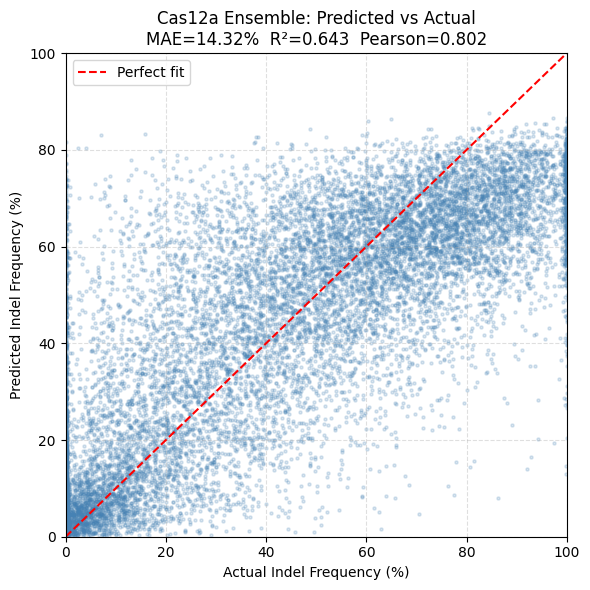


[추론 테스트]
--------------------------------------------------


서열    : ATCG[TTTA]ATCGATCGATCGATCGATCGATCGTA
PAM     : TTTA
예측 Indel frequency: 64.65%
Fold별 점수: ['0.5850', '0.6731', '0.6020', '0.7698', '0.6027']
결과: 높은 절단 효율 (High efficiency)
--------------------------------------------------
[Error] 서열 길이가 맞지 않습니다. (현재: 4bp / 필요: 34bp)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, BatchNormalization,
    Dropout, Bidirectional, LSTM, GlobalAveragePooling1D, LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project'
file_name = 'Copy of kim_2018_cas12a_dataset.xlsx'
file_path = os.path.join(base_path, file_name)

if os.path.exists(file_path):
    print(f"파일을 찾았습니다! 경로: {file_path}")
else:
    print(f"파일을 찾을 수 없습니다: {file_path}")


# =============================================================
# 1. 서열 인코딩
# =============================================================
def one_hot_encode(sequence):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    sequence = sequence.upper()
    return np.array([mapping.get(base, [0,0,0,0]) for base in sequence])


# =============================================================
# 2. 데이터 로더
# =============================================================
def load_cas12a_dataset(filepath):
    print("Cas12a 데이터 로딩 중...")

    if filepath.endswith(('.csv', '.txt')):
        df = pd.read_csv(filepath)
        if len(df.columns) < 2:
            df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith('.tsv'):
        df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(filepath)
    else:
        raise ValueError("Unsupported file format.")

    print(f"컬럼 목록: {list(df.columns)}")
    print(f"전체 행 수: {len(df)}")

    seq_col    = '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)'
    target_col = 'Indel freqeuncy\n(Background substracted, %)'

    original_len = len(df)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[seq_col, target_col])
    print(f"결측치 제거: {original_len} -> {len(df)}개")

    X, y = [], []
    for _, row in df.iterrows():
        seq   = str(row[seq_col]).strip().upper()
        score = float(row[target_col])

        if len(seq) > 34:
            seq = seq[:34]
        elif len(seq) < 34:
            seq = seq + ('N' * (34 - len(seq)))

        X.append(one_hot_encode(seq))
        y.append(score / 100.0)

    X = np.array(X, dtype=np.float32)   # (N, 34, 4)
    y = np.array(y, dtype=np.float32)   # (N,)
    y = np.clip(y, 0, 1)

    print(f"최종 데이터: X={X.shape}, y={y.shape}")
    print(f"타겟 범위  : {y.min()*100:.1f}% ~ {y.max()*100:.1f}%")
    return X, y


# =============================================================
# 3. 모델 설계 (초기 코드 구조 유지)
# =============================================================
def create_cas12a_model():
    input_layer = Input(shape=(34, 4), name='Input_Seq')

    x = Conv1D(filters=64, kernel_size=7, padding='same', name='Conv1')(input_layer)
    x = BatchNormalization(name='BN1')(x)
    x = LeakyReLU(negative_slope=0.1, name='LReLU1')(x)
    x = Dropout(0.3, name='Drop1')(x)

    x = Bidirectional(LSTM(32, return_sequences=True), name='BiLSTM')(x)
    x = Dropout(0.3, name='Drop2')(x)

    x = GlobalAveragePooling1D(name='GAP')(x)

    x = Dense(64, activation='relu', name='Dense1')(x)
    x = Dropout(0.3, name='Drop3')(x)

    output_layer = Dense(1, activation='sigmoid', name='Output')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mse',
        metrics=['mae']
    )
    return model


# =============================================================
# 4. 5-Fold 학습
# =============================================================
def train_5fold(X, y):
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    fold_results = []   # 각 fold의 검증 성능 저장
    fold_models  = []   # 각 fold 모델 저장

    print("\n===== 5-Fold 학습 시작 =====\n")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"---------- Fold {fold+1} / 5 ----------")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        print(f"학습: {len(X_train)}개 / 검증: {len(X_val)}개")

        model = create_cas12a_model()

        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        # fold별 저장
        save_path = os.path.join(model_save_dir, f'cas12a_fold{fold+1}.keras')
        model.save(save_path)
        print(f"저장 완료: {save_path}")

        # fold별 성능 측정
        y_pred     = model.predict(X_val, verbose=0).flatten()
        y_true_pct = y_val  * 100
        y_pred_pct = y_pred * 100

        mae     = mean_absolute_error(y_true_pct, y_pred_pct)
        r2      = r2_score(y_true_pct, y_pred_pct)
        pearson = pearsonr(y_true_pct, y_pred_pct)[0]

        print(f"Fold {fold+1} 결과 — MAE: {mae:.2f}%  R²: {r2:.4f}  Pearson R: {pearson:.4f}\n")

        fold_results.append({'fold': fold+1, 'mae': mae, 'r2': r2, 'pearson': pearson})
        fold_models.append(model)

    # 전체 요약
    print("========== 5-Fold 결과 요약 ==========")
    maes     = [r['mae']     for r in fold_results]
    r2s      = [r['r2']      for r in fold_results]
    pearsons = [r['pearson'] for r in fold_results]

    for r in fold_results:
        print(f"  Fold {r['fold']}: MAE={r['mae']:.2f}%  R²={r['r2']:.4f}  Pearson={r['pearson']:.4f}")

    print(f"\n  평균 MAE     : {np.mean(maes):.2f}% ± {np.std(maes):.2f}%")
    print(f"  평균 R²      : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
    print(f"  평균 Pearson : {np.mean(pearsons):.4f} ± {np.std(pearsons):.4f}")

    return fold_models, fold_results


# =============================================================
# 5. 앙상블 예측 및 시각화
# =============================================================
def evaluate_ensemble(fold_models, X, y):
    """
    5개 모델의 예측값을 평균내어 앙상블 성능 측정
    전체 데이터 기준 (학습+검증 모두 포함)
    """
    print("\n===== 앙상블 최종 성능 =====")

    preds = np.array([m.predict(X, verbose=0).flatten() for m in fold_models])
    y_pred_ensemble = np.mean(preds, axis=0)

    y_true_pct = y               * 100
    y_pred_pct = y_pred_ensemble * 100

    mae     = mean_absolute_error(y_true_pct, y_pred_pct)
    r2      = r2_score(y_true_pct, y_pred_pct)
    pearson = pearsonr(y_true_pct, y_pred_pct)[0]

    print(f"  MAE      : {mae:.2f}%")
    print(f"  R²       : {r2:.4f}")
    print(f"  Pearson R: {pearson:.4f}")

    # 시각화
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_pct, y_pred_pct, alpha=0.2, s=5, color='steelblue')
    plt.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect fit')
    plt.title(f"Cas12a Ensemble: Predicted vs Actual\nMAE={mae:.2f}%  R²={r2:.3f}  Pearson={pearson:.3f}")
    plt.xlabel("Actual Indel Frequency (%)")
    plt.ylabel("Predicted Indel Frequency (%)")
    plt.xlim(0, 100); plt.ylim(0, 100)
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return y_pred_ensemble


# =============================================================
# 6. 추론 함수 (앙상블)
# =============================================================
def predict_cas12a(sequence, fold_models):
    """
    입력: 34bp DNA 서열
    출력: 5개 모델 앙상블 raw score (0~1)
    """
    seq = sequence.strip().upper()

    if len(seq) != 34:
        print(f"[Error] 서열 길이가 맞지 않습니다. (현재: {len(seq)}bp / 필요: 34bp)")
        return None

    pam_seq    = seq[4:8]
    enc        = one_hot_encode(seq).reshape(1, 34, 4)

    scores = [float(m.predict(enc, verbose=0)[0][0]) for m in fold_models]
    score  = np.mean(scores)   # 앙상블 평균 (0~1 raw score)

    print(f"서열    : {seq[:4]}[{pam_seq}]{seq[8:]}")
    print(f"PAM     : {pam_seq}")
    print(f"예측 Indel frequency: {score*100:.2f}%")
    print(f"Fold별 점수: {[f'{s:.4f}' for s in scores]}")

    if score > 0.6:
        print("결과: 높은 절단 효율 (High efficiency)")
    elif score > 0.3:
        print("결과: 보통 절단 효율 (Moderate efficiency)")
    else:
        print("결과: 낮은 절단 효율 (Low efficiency)")

    return score  # 0~1 raw score 반환 (파이프라인용)


# =============================================================
# 7. 실행
# =============================================================
if __name__ == '__main__':

    if os.path.exists(file_path):
        X, y = load_cas12a_dataset(file_path)
        fold_models, fold_results = train_5fold(X, y)
        evaluate_ensemble(fold_models, X, y)
    else:
        print(f"파일을 찾을 수 없습니다: {file_path}")

    # --- 추론 테스트 ---
    print("\n[추론 테스트]")
    print("-" * 50)

    seq_test = "ATCGTTTAATCGATCGATCGATCGATCGATCGTA"  # 34bp
    predict_cas12a(seq_test, fold_models)

    print("-" * 50)
    seq_error = "ATCG"
    predict_cas12a(seq_error, fold_models)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
파일을 찾았습니다! 경로: /content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project/Copy of kim_2018_cas12a_dataset.xlsx
Cas12a 데이터 로딩 중...
컬럼 목록: ['50 bp synthetic target and target context sequence \n10 bp + PAM + 23 bp protospacer + 17 bp)', '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)', "20 bp guide sequence (5' to 3')", 'Indel frequency\n(%, Background)', 'Indel read count\n(Background)', 'Total read count\n(Background)', 'Indel freqeuncy\n(Cpf1 delivered,%)', 'Indel read count\n(Cpf1 delivered)', 'Total read count\n(Cpf1 delivered)', 'Indel freqeuncy\n(Background substracted, %)']
전체 행 수: 15002
결측치 제거: 15002 -> 15000개
최종 데이터: X_seq=(15000, 34, 4), X_feat=(15000, 354), y=(15000,)
타겟 범위  : 0.0% ~ 100.0%

===== 5-Fold 학습 시작 =====

---------- Fold 1 / 5 ----------
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - l

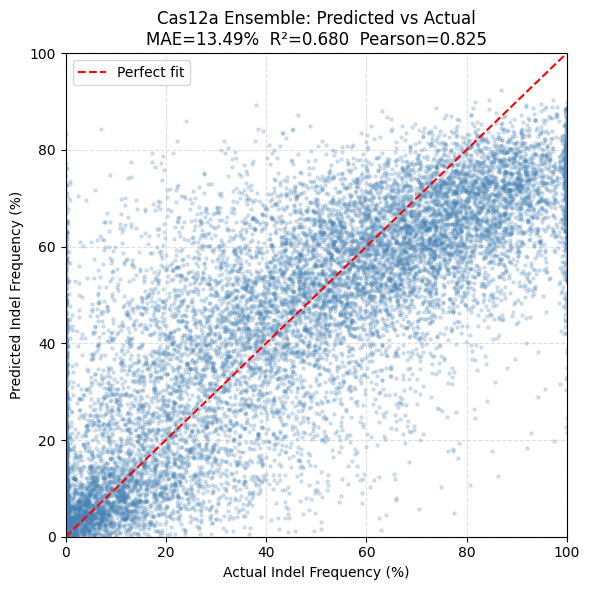


[추론 테스트]
--------------------------------------------------
서열    : ATCG[TTTA]ATCGATCGATCGATCGATCGATCGTA
PAM     : TTTA
예측 Indel frequency: 53.02%
Fold별 점수: ['0.5151', '0.4399', '0.5671', '0.5324', '0.5967']
결과: 보통 절단 효율 (Moderate efficiency)
--------------------------------------------------
[Error] 서열 길이가 맞지 않습니다. (현재: 4bp / 필요: 34bp)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, BatchNormalization,
    Dropout, Bidirectional, LSTM, GlobalAveragePooling1D, LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Colab Notebooks/Multi_Cas_Project'
file_name = 'Copy of kim_2018_cas12a_dataset.xlsx'
file_path = os.path.join(base_path, file_name)

if os.path.exists(file_path):
    print(f"파일을 찾았습니다! 경로: {file_path}")
else:
    print(f"파일을 찾을 수 없습니다: {file_path}")


def one_hot_encode(sequence):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
    sequence = sequence.upper()
    return np.array([mapping.get(base, [0,0,0,0]) for base in sequence])


def extract_seq_features(seq):
    protospacer = seq[8:31]

    gc_total = (protospacer.count('G') + protospacer.count('C')) / 23
    gc_seed  = (protospacer[-8:].count('G') + protospacer[-8:].count('C')) / 8

    dinuc_map = {a+b: i for i, (a, b) in enumerate(
        [(x, y) for x in 'ACGT' for y in 'ACGT']
    )}
    dinuc_features = np.zeros(22 * 16, dtype=np.float32)
    for i in range(22):
        pair = protospacer[i:i+2]
        if pair in dinuc_map:
            dinuc_features[i * 16 + dinuc_map[pair]] = 1.0

    return np.array([gc_total, gc_seed], dtype=np.float32), dinuc_features


def load_cas12a_dataset(filepath):
    print("Cas12a 데이터 로딩 중...")

    if filepath.endswith(('.csv', '.txt')):
        df = pd.read_csv(filepath)
        if len(df.columns) < 2:
            df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith('.tsv'):
        df = pd.read_csv(filepath, sep='\t')
    elif filepath.endswith(('.xls', '.xlsx')):
        df = pd.read_excel(filepath)
    else:
        raise ValueError("Unsupported file format.")

    print(f"컬럼 목록: {list(df.columns)}")
    print(f"전체 행 수: {len(df)}")

    seq_col    = '34 bp synthetic target and target context sequence\n(4 bp + PAM + 23 bp protospacer + 3 bp)'
    target_col = 'Indel freqeuncy\n(Background substracted, %)'

    original_len = len(df)
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[seq_col, target_col])
    print(f"결측치 제거: {original_len} -> {len(df)}개")

    X_seq, X_feat, y = [], [], []

    for _, row in df.iterrows():
        seq   = str(row[seq_col]).strip().upper()
        score = float(row[target_col])

        if len(seq) > 34:
            seq = seq[:34]
        elif len(seq) < 34:
            seq = seq + ('N' * (34 - len(seq)))

        gc_feat, dinuc_feat = extract_seq_features(seq)
        extra = np.concatenate([gc_feat, dinuc_feat])

        X_seq.append(one_hot_encode(seq))
        X_feat.append(extra)
        y.append(score / 100.0)

    X_seq  = np.array(X_seq,  dtype=np.float32)
    X_feat = np.array(X_feat, dtype=np.float32)
    y      = np.array(y,      dtype=np.float32)
    y      = np.clip(y, 0, 1)

    print(f"최종 데이터: X_seq={X_seq.shape}, X_feat={X_feat.shape}, y={y.shape}")
    print(f"타겟 범위  : {y.min()*100:.1f}% ~ {y.max()*100:.1f}%")
    return X_seq, X_feat, y



def create_cas12a_model():
    seq_input = Input(shape=(34, 4), name='Input_Seq')

    x1 = Conv1D(64, kernel_size=4,  padding='same', name='Conv_k4')(seq_input)
    x1 = BatchNormalization(name='BN_k4')(x1)
    x1 = LeakyReLU(negative_slope=0.1, name='LReLU_k4')(x1)

    x2 = Conv1D(64, kernel_size=8,  padding='same', name='Conv_k8')(seq_input)
    x2 = BatchNormalization(name='BN_k8')(x2)
    x2 = LeakyReLU(negative_slope=0.1, name='LReLU_k8')(x2)

    x3 = Conv1D(64, kernel_size=15, padding='same', name='Conv_k15')(seq_input)
    x3 = BatchNormalization(name='BN_k15')(x3)
    x3 = LeakyReLU(negative_slope=0.1, name='LReLU_k15')(x3)

    x = tf.keras.layers.Concatenate(name='Concat_conv')([x1, x2, x3])
    x = Dropout(0.4, name='Drop1')(x)

    x = Bidirectional(LSTM(32, return_sequences=True), name='BiLSTM')(x)
    x = Dropout(0.4, name='Drop2')(x)
    x = GlobalAveragePooling1D(name='GAP')(x)

    feat_input = Input(shape=(354,), name='Input_Feat')
    f = Dense(64, activation='relu', name='Feat_Dense')(feat_input)
    f = Dropout(0.3, name='Drop_feat')(f)

    x = tf.keras.layers.Concatenate(name='Concat_all')([x, f])
    x = Dense(64, activation='relu', name='Dense1')(x)
    x = Dropout(0.4, name='Drop3')(x)
    output = Dense(1, activation='sigmoid', name='Output')(x)

    model = Model(inputs=[seq_input, feat_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model



def train_5fold(X_seq, X_feat, y):
    model_save_dir = os.path.join(base_path, 'model_weights')
    os.makedirs(model_save_dir, exist_ok=True)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    fold_results = []
    fold_models  = []

    print("\n===== 5-Fold 학습 시작 =====\n")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_seq)):
        print(f"---------- Fold {fold+1} / 5 ----------")

        X_seq_tr,  X_seq_val  = X_seq[train_idx],  X_seq[val_idx]
        X_feat_tr, X_feat_val = X_feat[train_idx], X_feat[val_idx]
        y_train,   y_val      = y[train_idx],       y[val_idx]

        model = create_cas12a_model()

        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6
        )

        model.fit(
            [X_seq_tr, X_feat_tr], y_train,
            validation_data=([X_seq_val, X_feat_val], y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        save_path = os.path.join(model_save_dir, f'cas12a_fold{fold+1}.keras')
        model.save(save_path)
        print(f"저장 완료: {save_path}")

        y_pred     = model.predict([X_seq_val, X_feat_val], verbose=0).flatten()
        y_true_pct = y_val  * 100
        y_pred_pct = y_pred * 100

        mae     = mean_absolute_error(y_true_pct, y_pred_pct)
        r2      = r2_score(y_true_pct, y_pred_pct)
        pearson = pearsonr(y_true_pct, y_pred_pct)[0]

        fold_results.append({'fold': fold+1, 'mae': mae, 'r2': r2, 'pearson': pearson})
        fold_models.append(model)


    return fold_models, fold_results


def evaluate_ensemble(fold_models, X_seq, X_feat, y):
    print("\n===== 앙상블 최종 성능 =====")

    preds = np.array([
        m.predict([X_seq, X_feat], verbose=0).flatten()
        for m in fold_models
    ])
    y_pred_ensemble = np.mean(preds, axis=0)

    y_true_pct = y               * 100
    y_pred_pct = y_pred_ensemble * 100

    mae      = mean_absolute_error(y_true_pct, y_pred_pct)
    r2       = r2_score(y_true_pct, y_pred_pct)
    pearson  = pearsonr(y_true_pct, y_pred_pct)[0]
    residuals = y_true_pct - y_pred_pct

    print(f"  MAE      : {mae:.2f}%")
    print(f"\n구간별 MAE")
    print(f"  저효율(0~20%)   : {np.mean(np.abs(residuals[y_true_pct < 20])):.2f}%")
    print(f"  중효율(20~60%)  : {np.mean(np.abs(residuals[(y_true_pct >= 20) & (y_true_pct < 60)])):.2f}%")
    print(f"  고효율(60~100%) : {np.mean(np.abs(residuals[y_true_pct >= 60])):.2f}%")

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_pct, y_pred_pct, alpha=0.2, s=5, color='steelblue')
    plt.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect fit')
    plt.title(f"Cas12a Ensemble: Predicted vs Actual\nMAE={mae:.2f}%  R²={r2:.3f}  Pearson={pearson:.3f}")
    plt.xlabel("Actual Indel Frequency (%)")
    plt.ylabel("Predicted Indel Frequency (%)")
    plt.xlim(0, 100); plt.ylim(0, 100)
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



def predict_cas12a(sequence, fold_models):
    """
    입력: 34bp DNA 서열
    출력: 5개 모델 앙상블 raw score (0~1)
    """
    seq = sequence.strip().upper()

    if len(seq) != 34:
        print(f"[Error] 서열 길이가 맞지 않습니다. (현재: {len(seq)}bp / 필요: 34bp)")
        return None

    pam_seq = seq[4:8]
    enc     = one_hot_encode(seq).reshape(1, 34, 4)

    gc_feat, dinuc_feat = extract_seq_features(seq)
    feat = np.concatenate([gc_feat, dinuc_feat]).reshape(1, 354)

    scores = [float(m.predict([enc, feat], verbose=0)[0][0]) for m in fold_models]
    score  = np.mean(scores)

    print(f"서열    : {seq[:4]}[{pam_seq}]{seq[8:]}")
    print(f"PAM     : {pam_seq}")
    print(f"예측 Indel frequency: {score*100:.2f}%")
    print(f"Fold별 점수: {[f'{s:.4f}' for s in scores]}")

    if score > 0.6:
        print("결과: 높은 절단 효율 (High efficiency)")
    elif score > 0.3:
        print("결과: 보통 절단 효율 (Moderate efficiency)")
    else:
        print("결과: 낮은 절단 효율 (Low efficiency)")

    return score  # 0~1 raw score 반환 (파이프라인용)


if __name__ == '__main__':

    if os.path.exists(file_path):
        X_seq, X_feat, y = load_cas12a_dataset(file_path)
        fold_models, fold_results = train_5fold(X_seq, X_feat, y)
        evaluate_ensemble(fold_models, X_seq, X_feat, y)
    else:
        print(f"파일을 찾을 수 없습니다: {file_path}")

    print("\n[추론 테스트]")
    print("-" * 50)
    seq_test = "ATCGTTTAATCGATCGATCGATCGATCGATCGTA"
    predict_cas12a(seq_test, fold_models)

    print("-" * 50)
    seq_error = "ATCG"
    predict_cas12a(seq_error, fold_models)